# Notebook 9 – Random Forest


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## Ensemble Learning

**What it is:** the idea of combining several models together to get a
prediction that's better than any one of them alone. A single Decision
Tree, as seen in Notebook 8, is powerful but unstable, a small change in
the training data can produce a very different tree, and an unrestricted
tree easily overfits. Ensemble methods deal with this by training *many*
models and combining their outputs, letting their individual errors
average out. Random Forest is one specific, very popular ensemble method,
built from many Decision Trees.

## Bagging (Bootstrap Aggregating)

**What it is:** the ensemble technique Random Forest is built on. Instead
of training one model on the full training set, bagging trains *many*
copies of the same kind of model, each on its own random **bootstrap
sample** — a sample of the same size as the original training set, drawn
*with replacement*, so some rows appear multiple times and others don't
appear at all in any given sample. Each model sees a slightly different
version of the data, then their predictions are combined (see "Voting"
below).

In [2]:
# Illustrating a bootstrap sample directly
rng = np.random.default_rng(42)
original_indices = df.index[:10].to_numpy()
bootstrap_sample = rng.choice(original_indices, size=10, replace=True)

print("Original row indices:  ", original_indices)
print("One bootstrap sample:  ", np.sort(bootstrap_sample))
print("Unique rows included:  ", len(np.unique(bootstrap_sample)), "out of 10",
      "(some rows repeat, others are left out entirely)")

Original row indices:   [0 1 2 3 4 5 6 7 8 9]
One bootstrap sample:   [0 0 0 2 4 4 6 6 7 8]
Unique rows included:   6 out of 10 (some rows repeat, others are left out entirely)


## Random Forest

**What it does:** trains a large collection ("forest") of Decision Trees,
each one on its own bootstrap sample of the training data, and combines
all of their predictions into one final answer. It's bagging applied
specifically to Decision Trees, plus one more trick on top (random
feature selection, below) that makes the individual trees even more
different from each other.

## Multiple Decision Trees & Random Feature Selection

A plain bagging ensemble of Decision Trees already helps, but if one
feature is extremely predictive, nearly every bootstrapped tree will
still choose to split on that same feature near the root, making the
trees end up quite similar to each other (and similarly correlated in
their mistakes). Random Forest adds a second source of randomness on top
of the bootstrap samples to fix this: at *each split*, instead of
considering every available feature, each tree only considers a random
subset of them. This forces different trees to discover different
patterns, making the forest as a whole more diverse, and diversity is
exactly what makes combining many models actually help.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X = df[feature_cols]
y = df["IsCancelled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

forest_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

print(classification_report(y_test, forest_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    106233
           1       0.42      0.00      0.01      1858

    accuracy                           0.98    108091
   macro avg       0.70      0.50      0.50    108091
weighted avg       0.97      0.98      0.97    108091



## Voting

**What it is:** how a Random Forest turns its many individual trees'
predictions into one final prediction. For classification, this is
**majority voting** (also called "hard voting" when only the winning
class counts, or "soft voting" when the trees' predicted *probabilities*
are averaged instead — scikit-learn uses soft voting by default). Each
tree "votes" for a class, and the forest predicts whichever class gets
the most support.

Below, the actual votes from the first 10 trees in the trained forest are
tallied by hand, for a single test row, to show exactly how the forest's
final prediction gets assembled.

In [4]:
sample_row = X_test.iloc[[0]]

individual_votes = [int(tree.predict(sample_row.values)[0]) for tree in forest_model.estimators_[:10]]
print("Votes from the first 10 individual trees:", individual_votes)

from collections import Counter
vote_counts = Counter(individual_votes)
print("Vote tally:", dict(vote_counts))

# Soft voting: scikit-learn actually averages predicted probabilities across ALL trees, not just 10
print("\nForest's actual predicted probabilities [not cancelled, cancelled]:",
      np.round(forest_model.predict_proba(sample_row)[0], 4))
print("Forest's final prediction:", forest_model.predict(sample_row)[0])

Votes from the first 10 individual trees: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Vote tally: {0: 10}

Forest's actual predicted probabilities [not cancelled, cancelled]: [0.9893 0.0107]
Forest's final prediction: 0


## Feature Importance

**What it is:** a score, for each feature, of how much that feature
contributed to reducing impurity across every split, in every tree, in
the forest (weighted by how many samples reached each split). It's a
natural byproduct of how Random Forest already works internally, and one
of the main reasons people like it: unlike a single Decision Tree's
splits, which can be sensitive to the specific training data, feature
importance averaged over hundreds of trees gives a fairly stable read on
which features actually matter.

UnitPrice          0.5622
AbsQuantity        0.1608
IsInternational    0.1608
Month              0.1161
dtype: float64


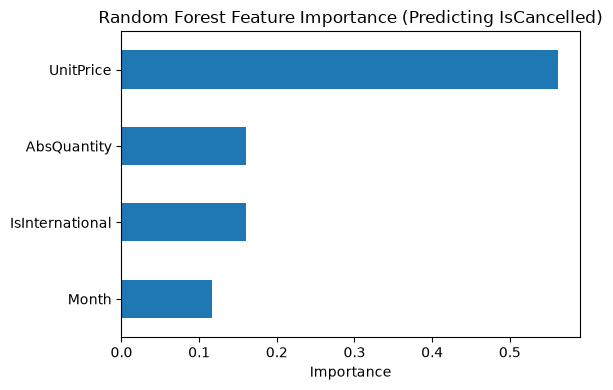

In [5]:
importances = pd.Series(forest_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.round(4))

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Predicting IsCancelled)")
plt.tight_layout()
plt.show()

## Overfitting

Random Forest is far more resistant to overfitting than a single
unrestricted Decision Tree, because averaging many trees, each trained on
a different bootstrap sample with a different random subset of features
at each split, smooths out the individual trees' tendency to memorize
noise. It isn't *immune*, however: with enough trees that are each grown
too deep, on too small a dataset, a forest can still overfit, just far
less dramatically and less easily than a single tree does.

Below, the gap between training and test accuracy is compared for an
unrestricted single Decision Tree versus the Random Forest, using the
same data.

In [6]:
unrestricted_tree = DecisionTreeClassifier(random_state=42)
unrestricted_tree.fit(X_train, y_train)

print(f"{'Model':30s} {'Train Accuracy':>15s} {'Test Accuracy':>15s} {'Train-Test Gap':>15s}")
for name, model in [("Unrestricted Decision Tree", unrestricted_tree), ("Random Forest (200 trees)", forest_model)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:30s} {train_acc:15.4f} {test_acc:15.4f} {train_acc - test_acc:15.4f}")

Model                           Train Accuracy   Test Accuracy  Train-Test Gap
Unrestricted Decision Tree              0.9852          0.9822          0.0030
Random Forest (200 trees)               0.9830          0.9828          0.0002


## Decision Tree vs. Random Forest

| | Decision Tree | Random Forest |
|---|---|---|
| **What it is** | One flowchart of yes/no questions | Many Decision Trees combined |
| **Training data per model** | The full training set | Each tree gets its own bootstrap sample |
| **Features considered per split** | All available features | A random subset, per split, per tree |
| **Overfitting risk** | High if left unrestricted (or depth-limited) | Much lower — errors average out across trees |
| **Stability** | Sensitive to small changes in training data; can look very different if retrained | Stable — no single tree dominates the outcome |
| **Interpretability** | Very high — you can draw and read the exact flowchart | Low — hundreds of trees can't be visualized individually |
| **Prediction speed** | Fast (one tree) | Slower (must run every tree, then combine) |
| **Typical accuracy** | Good baseline, often outperformed by ensembles | Usually higher, at the cost of speed and interpretability |

Below, the depth-limited single tree from Notebook 8, the unrestricted
single tree, and the Random Forest are lined up side by side on identical
test data, to make the trade-off concrete rather than theoretical.

In [7]:
shallow_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
shallow_tree.fit(X_train, y_train)

comparison = pd.DataFrame({
    "Model": ["Decision Tree (max_depth=4)", "Decision Tree (unrestricted)", "Random Forest (200 trees)"],
    "Train Accuracy": [
        accuracy_score(y_train, shallow_tree.predict(X_train)),
        accuracy_score(y_train, unrestricted_tree.predict(X_train)),
        accuracy_score(y_train, forest_model.predict(X_train)),
    ],
    "Test Accuracy": [
        accuracy_score(y_test, shallow_tree.predict(X_test)),
        accuracy_score(y_test, unrestricted_tree.predict(X_test)),
        accuracy_score(y_test, forest_model.predict(X_test)),
    ],
})
comparison["Train Accuracy"] = comparison["Train Accuracy"].round(4)
comparison["Test Accuracy"] = comparison["Test Accuracy"].round(4)
comparison["Train-Test Gap"] = (comparison["Train Accuracy"] - comparison["Test Accuracy"]).round(4)
comparison

,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Decision Tree (max_depth=4),0.9829,0.9827,0.0002
1,Decision Tree (unrestricted),0.9852,0.9822,0.0030
2,Random Forest (200 trees),0.9830,0.9828,0.0002


## Advantages

* **Strong, reliable accuracy** across a wide range of problems, often
  with little tuning, thanks to combining many trees.
* **Resistant to overfitting** compared to a single unrestricted Decision
  Tree, since averaging many diverse trees smooths out individual trees'
  mistakes.
* **Handles both numeric and categorical features** without needing
  scaling or normalization (each tree just asks threshold questions).
* **Built-in feature importance**, useful for understanding a dataset
  even beyond just making predictions.
* **Robust to outliers and noisy features**, since a single unusual
  row or a weak feature is unlikely to affect every tree the same way.

## Limitations

* **Loses interpretability.** A single Decision Tree can be drawn and read
  by a human; a forest of hundreds of trees can't be inspected the same
  way, only summarized (e.g. through feature importance).
* **Slower to train and predict** than a single tree, since it means
  training (and running) many trees instead of one.
* **Larger memory footprint** — storing hundreds of trees takes
  considerably more space than storing one.
* **Can still struggle with highly imbalanced classes** (as seen above,
  where the rare "Cancelled" class remains hard to predict well) — it
  reduces overfitting, but doesn't invent signal that isn't in the
  data.
* **Diminishing returns** from adding more trees — accuracy improves
  quickly at first, then flattens, while training time keeps growing.